<table><tr><th><div style='padding:15px;color:#030aa7;font-size:240%;text-align:center;font-weight:bold;font-family:Georgia,serif'>Comprendre une distribution — e‑Brasil</div></th></tr></table>
<table><tr><th><div style='padding:15px;color:#e50000;font-size:240%;text-align:center;font-style:italic;font-weight:bold;font-family:Georgia,serif'>Comment les observations se répartissent-elles ?</div></th></tr></table>

<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_3.png' width='1024'></div>
<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_3_description.png' width='1024'></div>

<div style='padding:15px;color:#030aa7;font-family:Georgia,serif'>Atelier BI · Famille 03 · 6 graphiques × 3 bibliothèques</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>

Les tables locales constituent la source ; aucune base de démonstration ne les remplace. Les articles sont agrégés au niveau commande avant jointure. Les commandes sans article ou sans livraison restent manquantes pour les mesures concernées. Les délais sont recalculés : les colonnes de durée préexistantes ne sont pas présumées documentées. L’unité monétaire BRL est une hypothèse de contexte ; les graphiques indiquent « montant source ».

**Objectif :** construire les six représentations de cette famille sur les données réelles, comparer les encodages et interpréter leurs limites. Les trois variantes utilisent exactement la même table préparée. Les constructions composites Seaborn sont signalées : cette bibliothèque ne propose pas tous les types nativement.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Sommaire</div></b>

1. Histogramme
2. Densité ou KDE
3. Répartition cumulée ou ECDF
4. Boîte à moustaches
5. Violon
6. Points individuels ou swarm

Exécution : ouvrir le dossier extrait, sélectionner un noyau Python avec les dépendances de `requirements.txt`, puis **Redémarrer le noyau et tout exécuter**. Les résultats sont déjà enregistrés. Adapter `config_donnees.json` si les fichiers changent de place.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import des bibliothèques</div></b>

In [1]:
NOM_PROJET = '03_ecommerce'
from pathlib import Path
import os, json, warnings
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Wedge
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
import networkx as nx
import squarify

get_ipython().run_line_magic('matplotlib', 'inline')
SEED = 42
palette = ["#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
           "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe"]
sns.set_theme(style='darkgrid', palette=palette, context='notebook', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 110})
pio.templates['bi_modele'] = pio.templates['plotly_white']
pio.templates['bi_modele'].layout.colorway = palette
pio.templates.default = 'bi_modele'
pio.renderers.default = 'plotly_mimetype'
px.defaults.color_discrete_sequence = palette
EXPORTER = False  # True : PNG statiques et HTML interactifs dans repertoire.images.
repertoireImages = Path('repertoire.images') / NOM_PROJET

def sauvegarderImage(nom, fig=None):
    fig = fig if fig is not None else plt.gcf()
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.savefig(repertoireImages / (nom + '.png'), dpi=180, bbox_inches='tight')

def terminer(ax, titre, xlabel=None, ylabel=None):
    ax.set_title(titre, loc='left', fontweight='bold', pad=14)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.figure.tight_layout()
    sauvegarderImage(ID_GRAPHIQUE + '_' + BIBLIOTHEQUE, ax.figure)
    plt.show()
    plt.close(ax.figure)

def montrer_plotly(fig, titre):
    fig.update_layout(title=titre, width=1000, height=520,
                      margin=dict(l=70, r=45, t=90, b=75),
                      font=dict(family='Arial', size=13))
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.write_html(repertoireImages / (ID_GRAPHIQUE + '_plotly.html'), include_plotlyjs=True)
    fig.show()

def creer_axes(seaborn=False, **kwargs):
    # Matplotlib reste autonome ; Seaborn garde le style et la palette du modèle.
    plt.style.use('default')
    if seaborn: sns.set_theme(style='darkgrid', palette=palette, context='notebook')
    return plt.subplots(figsize=(11, 5), **kwargs)

print('Versions :', 'pandas', pd.__version__, 'seaborn', sns.__version__,
      'plotly', __import__('plotly').__version__, 'matplotlib', __import__('matplotlib').__version__)

Versions : pandas 2.3.3 seaborn 0.13.2 plotly 7.1.0 matplotlib 3.10.9


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

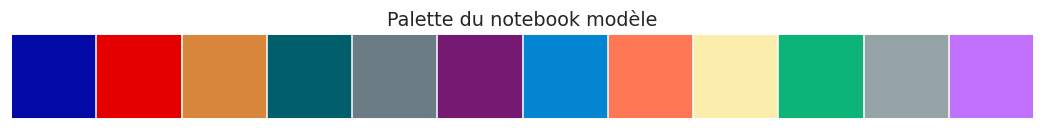

In [2]:
sns.palplot(sns.color_palette(palette))
plt.title('Palette du notebook modèle')
plt.show()
plt.close('all')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

<table><tr><th style="background:#053061;color:white">Colonne</th><th style="background:#053061;color:white">Description</th></tr><tr><td>orders.order_id</td><td>Une ligne par commande</td></tr><tr><td>items.price / freight_value</td><td>Prix article et frais de port ; montants supposés BRL pour ce jeu brésilien</td></tr><tr><td>customers.state</td><td>État du client</td></tr><tr><td>purchase_timestamp / delivered_customer</td><td>Dates d’achat et de livraison</td></tr><tr><td>delai_jours</td><td>Durée achat → livraison calculée à partir des horodatages</td></tr><tr><td>retard_jours</td><td>Écart entre jour livré et jour estimé ; positif = retard</td></tr></table>

In [3]:
CHEMINS = {'meteo': '/opt/spark/data/meteo.gzip', 'web': '/opt/spark/data/Web.Server.Access10.gzip', 'ecommerce': '/opt/spark/notebooks/ecommerce'}
configuration = Path('config_donnees.json')
if configuration.exists():
    CHEMINS.update(json.loads(configuration.read_text(encoding='utf-8')))
for cle in CHEMINS:
    CHEMINS[cle] = os.environ.get('BI_' + cle.upper(), CHEMINS[cle])
assert Path(CHEMINS['ecommerce']).exists(), 'Vérifier config_donnees.json'

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Contrôle des données et préparation</div></b>

In [4]:
racine = Path(CHEMINS['ecommerce'])
orders = pd.read_parquet(racine / 'orders.parquet')
items = pd.read_parquet(racine / 'items.parquet')
customers = pd.read_parquet(racine / 'customers.parquet')
assert orders['order_id'].is_unique, 'order_id doit être unique dans orders'
assert customers['customer_id'].is_unique, 'customer_id doit être unique'
assert not items.duplicated(['order_id','order_item_id']).any(), 'Doublons d’articles'
# Agréger les articles AVANT la jointure empêche de multiplier les commandes.
montants = items.groupby('order_id').agg(montant_articles=('price','sum'),
                                        frais_port=('freight_value','sum'),
                                        nb_articles=('order_item_id','size')).reset_index()
donnees = orders.merge(montants, on='order_id', how='left', validate='one_to_one')
donnees = donnees.merge(customers[['customer_id','state']], on='customer_id',
                        how='left', validate='many_to_one')
for col in ['purchase_timestamp','approved_at','delivered_carrier','delivered_customer','estimated_delivery']:
    donnees[col] = pd.to_datetime(donnees[col], errors='coerce')
donnees['total_commande'] = donnees['montant_articles'] + donnees['frais_port']
donnees['delai_jours'] = (donnees['delivered_customer'] - donnees['purchase_timestamp']).dt.total_seconds()/86400
print('Délais négatifs masqués :', donnees['delai_jours'].lt(0).sum())
donnees.loc[donnees['delai_jours'].lt(0), 'delai_jours'] = np.nan
# La promesse est une date : comparer les jours calendaires et non minuit à l’heure réelle.
donnees['retard_jours'] = (donnees['delivered_customer'].dt.normalize() - donnees['estimated_delivery'].dt.normalize()).dt.days
donnees['state'] = donnees['state'].fillna('Inconnu')
print('Commandes :', len(donnees), '; sans articles :', donnees['total_commande'].isna().sum())
print('Période achat :', donnees.purchase_timestamp.min(), '→', donnees.purchase_timestamp.max())
print('Montants d’articles et port, pas un bénéfice ni un revenu comptable reconnu.')
assert len(donnees) == len(orders)
display(donnees[['montant_articles','frais_port','total_commande','delai_jours']].describe().T)

Délais négatifs masqués : 0
Commandes : 99441 ; sans articles : 775
Période achat : 2016-09-04 21:15:19 → 2018-10-17 17:30:18
Montants d’articles et port, pas un bénéfice ni un revenu comptable reconnu.


,count,mean,std,min,25%,50%,75%,max
montant_articles,98666.0,137.754076,210.645145,0.850000,45.900000,86.900000,149.900000,13440.000000
frais_port,98666.0,22.823562,21.650909,0.000000,13.850000,17.170000,24.040000,1794.960000
total_commande,98666.0,160.577638,220.466087,9.590000,61.980000,105.290000,176.870000,13664.080000
delai_jours,96476.0,12.558702,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Statistiques descriptives et analyse de données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>1 — Histogramme</div></b>

Étudier les délais de livraison des commandes livrées. Variable : délai Q. Les trois bibliothèques partagent exactement 30 classes sur toute l’étendue, sans retirer la queue.

In [5]:
population=donnees.loc[donnees.delai_jours.notna() & donnees.status.eq('delivered')].copy()
x=population.delai_jours.to_numpy()
assert len(x)>1
display(population.delai_jours.describe(percentiles=[.5,.9,.99]))
bins=np.linspace(x.min(),x.max(),31)

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
50%         10.217477
90%         23.096377
99%         46.050262
max        209.628611
Name: delai_jours, dtype: float64

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

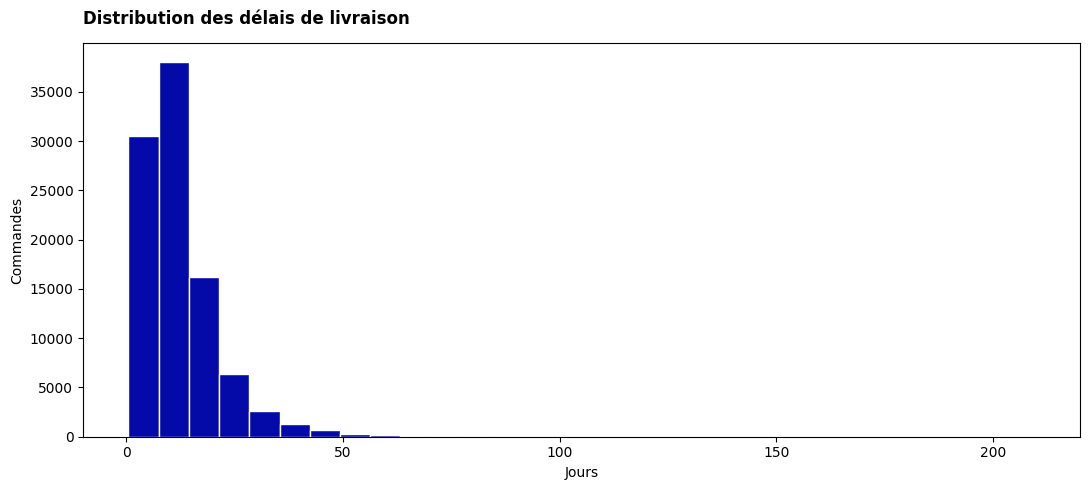

In [6]:
ID_GRAPHIQUE = '03_01'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.hist(x,bins=bins,color=palette[0],edgecolor='white')
terminer(ax,'Distribution des délais de livraison','Jours','Commandes')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

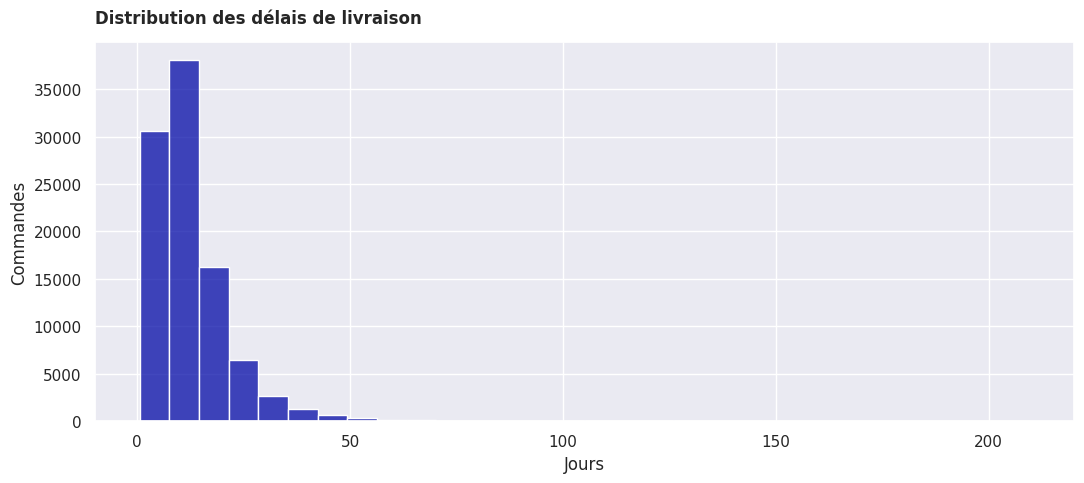

In [7]:
ID_GRAPHIQUE = '03_01'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.histplot(x=x,bins=bins,color=palette[0],ax=ax)
terminer(ax,'Distribution des délais de livraison','Jours','Commandes')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [8]:
ID_GRAPHIQUE = '03_01'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure(go.Histogram(x=x,xbins=dict(start=float(bins[0]),end=float(bins[-1]),size=float(bins[1]-bins[0]))))
fig.update_layout(xaxis_title='Jours',yaxis_title='Commandes')
montrer_plotly(fig,'Distribution des délais de livraison')

**À lire dans les trois variantes :** Étudier les délais de livraison des commandes livrées. Variable : délai Q. Les trois bibliothèques partagent exactement 30 classes sur toute l’étendue, sans retirer la queue.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>2 — Densité estimée</div></b>

Comparer la forme lissée à l’histogramme. Variable : délai Q. KDE gaussienne, règle de Scott, courbe coupée à zéro ; ce lissage peut avoir une masse théorique négative et un biais de bord.

In [9]:
population=donnees.loc[donnees.delai_jours.notna() & donnees.status.eq('delivered')].copy()
x=population.delai_jours.to_numpy()
assert len(x)>1
display(population.delai_jours.describe(percentiles=[.5,.9,.99]))
grille=np.linspace(0,x.max(),300)
kde=gaussian_kde(x,bw_method='scott')
densite=kde(grille)

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
50%         10.217477
90%         23.096377
99%         46.050262
max        209.628611
Name: delai_jours, dtype: float64

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

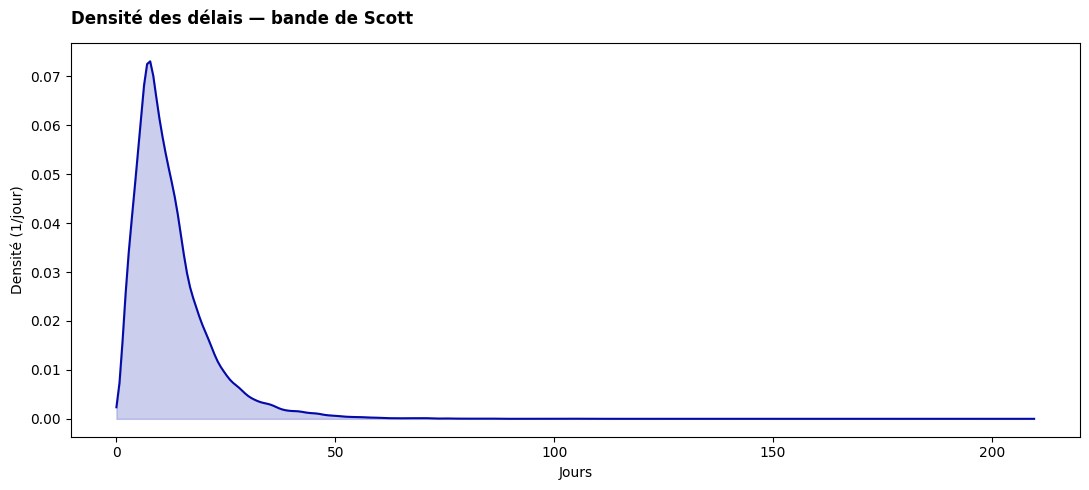

In [10]:
ID_GRAPHIQUE = '03_02'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.plot(grille,densite,color=palette[0]);ax.fill_between(grille,densite,alpha=.2,color=palette[0])
terminer(ax,'Densité des délais — bande de Scott','Jours','Densité (1/jour)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

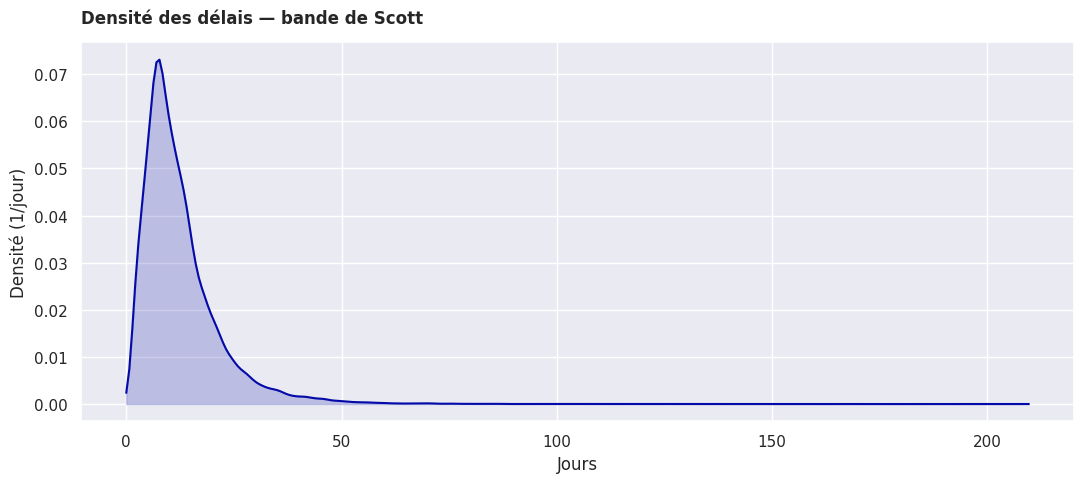

In [11]:
ID_GRAPHIQUE = '03_02'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
# Calcul commun pour garantir la même bande et la même grille.
sns.lineplot(x=grille,y=densite,estimator=None,color=palette[0],ax=ax);ax.fill_between(grille,densite,alpha=.2,color=palette[0])
terminer(ax,'Densité des délais — bande de Scott','Jours','Densité (1/jour)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

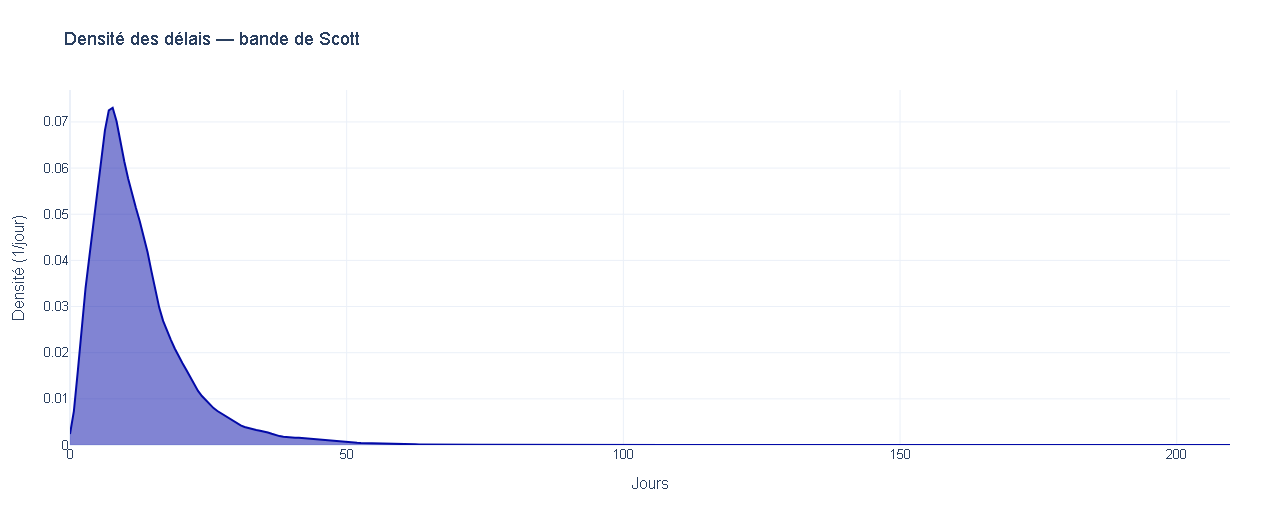

In [12]:
ID_GRAPHIQUE = '03_02'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure(go.Scatter(x=grille,y=densite,fill='tozeroy',mode='lines'))
fig.update_layout(xaxis_title='Jours',yaxis_title='Densité (1/jour)')
montrer_plotly(fig,'Densité des délais — bande de Scott')

**À lire dans les trois variantes :** Comparer la forme lissée à l’histogramme. Variable : délai Q. KDE gaussienne, règle de Scott, courbe coupée à zéro ; ce lissage peut avoir une masse théorique négative et un biais de bord.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>3 — Répartition cumulée empirique</div></b>

Lire la proportion de commandes livrées sous un délai donné. Variable : délai Q ; tous les délais valides sont utilisés, sans estimation de densité.

In [13]:
population=donnees.loc[donnees.delai_jours.notna() & donnees.status.eq('delivered')].copy()
x=population.delai_jours.to_numpy()
assert len(x)>1
display(population.delai_jours.describe(percentiles=[.5,.9,.99]))

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
50%         10.217477
90%         23.096377
99%         46.050262
max        209.628611
Name: delai_jours, dtype: float64

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

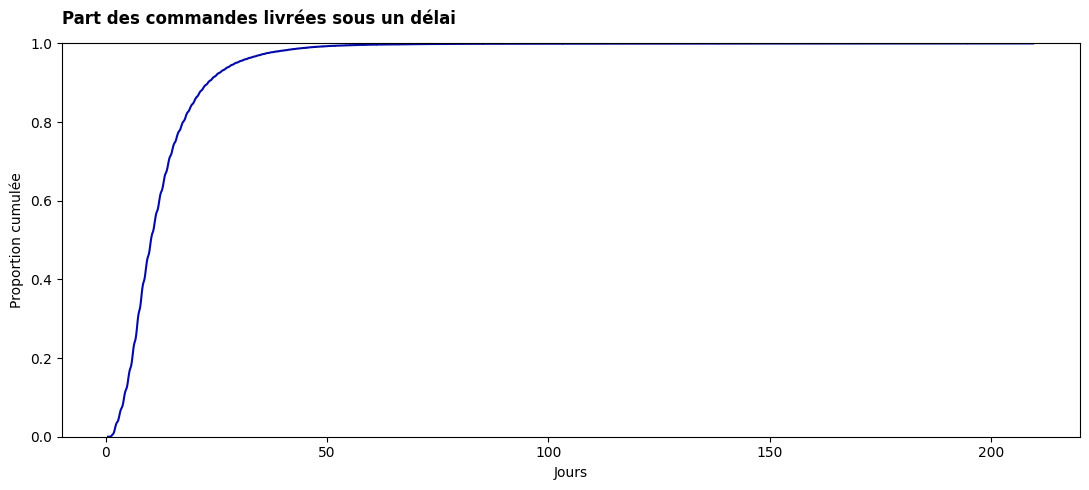

In [14]:
ID_GRAPHIQUE = '03_03'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
xs=np.sort(x);ax.step(xs,np.arange(1,len(xs)+1)/len(xs),where='post',color=palette[0]);ax.set_ylim(0,1)
terminer(ax,'Part des commandes livrées sous un délai','Jours','Proportion cumulée')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

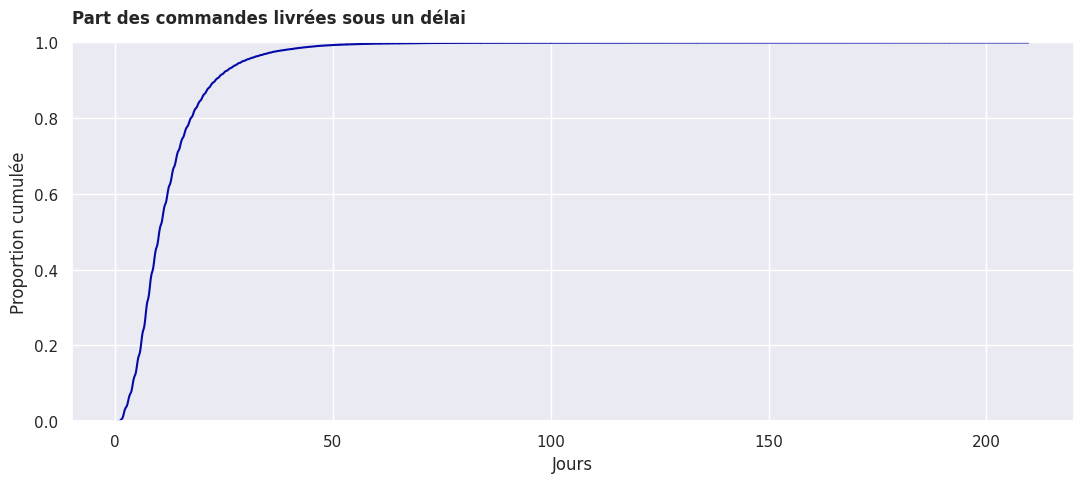

In [15]:
ID_GRAPHIQUE = '03_03'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.ecdfplot(x=x,ax=ax,color=palette[0]);ax.set_ylim(0,1)
terminer(ax,'Part des commandes livrées sous un délai','Jours','Proportion cumulée')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [16]:
ID_GRAPHIQUE = '03_03'
BIBLIOTHEQUE = 'plotly'
fig=px.ecdf(population,x='delai_jours',labels={'delai_jours':'Jours','probability':'Proportion cumulée'})
fig.update_yaxes(title='Proportion cumulée',range=[0,1.02])
montrer_plotly(fig,'Part des commandes livrées sous un délai')

**À lire dans les trois variantes :** Lire la proportion de commandes livrées sous un délai donné. Variable : délai Q ; tous les délais valides sont utilisés, sans estimation de densité.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>4 — Boîtes à moustaches</div></b>

Comparer les délais dans les cinq états avec le plus de commandes livrées. Variables : état C + délai Q. Moustaches à 1,5 IQR ; les points extrêmes restent affichés.

In [17]:
population=donnees.loc[donnees.delai_jours.notna() & donnees.status.eq('delivered')].copy()
x=population.delai_jours.to_numpy()
assert len(x)>1
display(population.delai_jours.describe(percentiles=[.5,.9,.99]))
etats=population.state.value_counts().head(5).index.tolist()
a=population.loc[population.state.isin(etats)].copy()
display(a.groupby('state').delai_jours.agg(['size','median']))

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
50%         10.217477
90%         23.096377
99%         46.050262
max        209.628611
Name: delai_jours, dtype: float64

,size,median
state,,
MG,11354,10.313513
PR,4923,10.425509
RJ,12350,12.041644
RS,5344,13.177488
SP,40494,7.210272


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

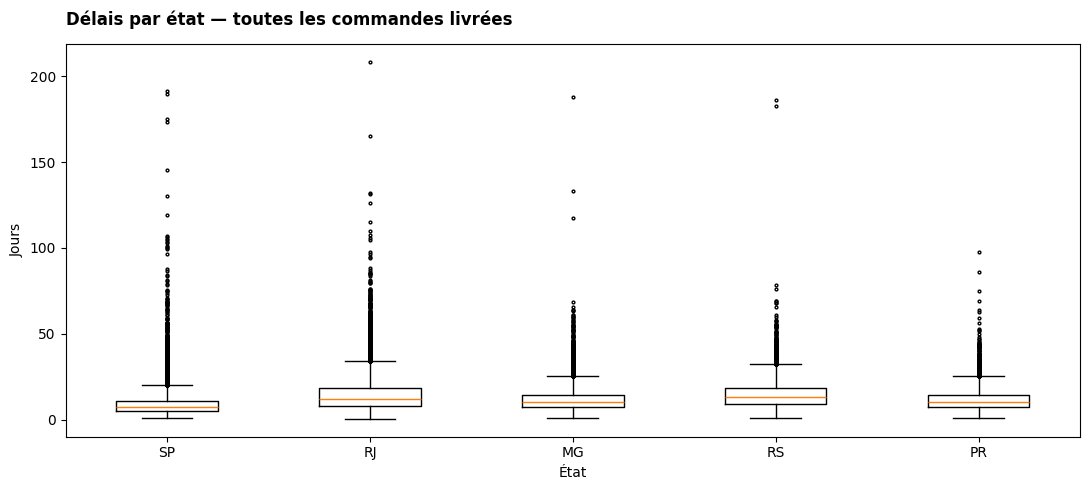

In [18]:
ID_GRAPHIQUE = '03_04'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.boxplot([a.loc[a.state.eq(s),'delai_jours'] for s in etats],tick_labels=etats,whis=1.5,flierprops={'markersize':2})
terminer(ax,'Délais par état — toutes les commandes livrées','État','Jours')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

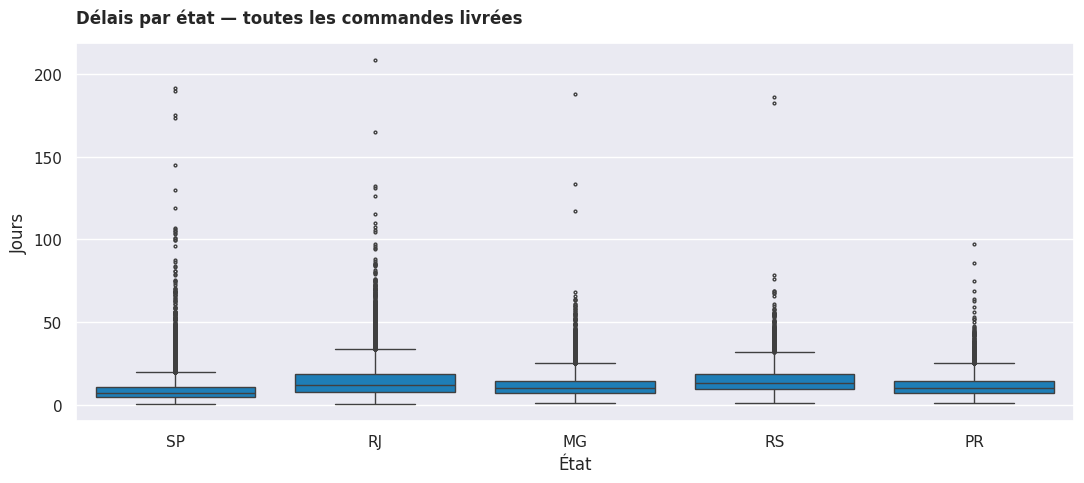

In [19]:
ID_GRAPHIQUE = '03_04'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.boxplot(data=a,x='state',y='delai_jours',order=etats,color=palette[6],whis=1.5,fliersize=2,ax=ax)
terminer(ax,'Délais par état — toutes les commandes livrées','État','Jours')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

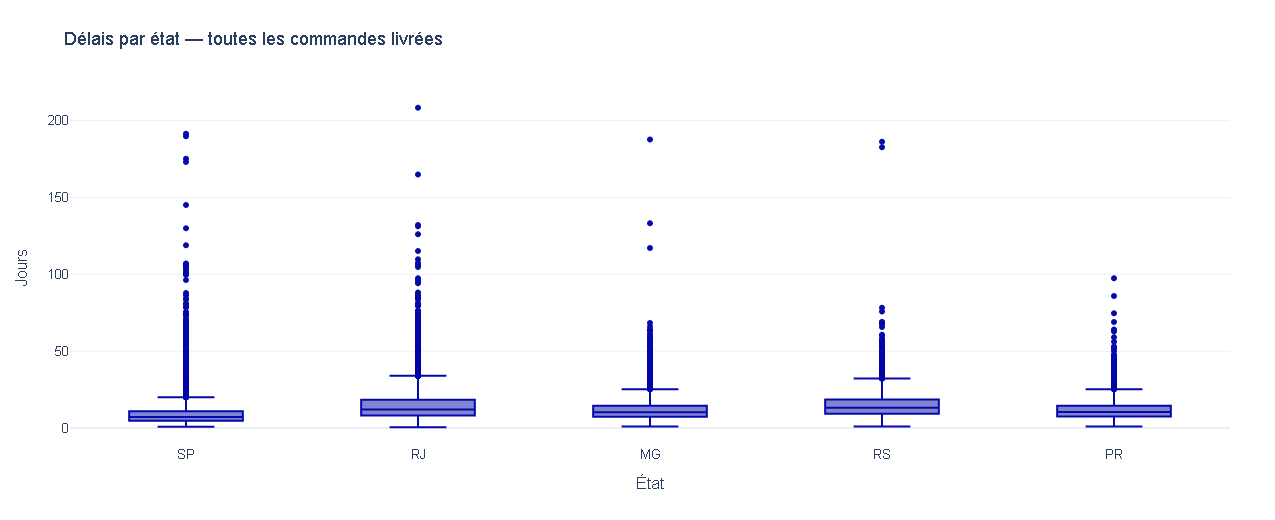

In [20]:
ID_GRAPHIQUE = '03_04'
BIBLIOTHEQUE = 'plotly'
fig=px.box(a,x='state',y='delai_jours',category_orders={'state':etats},points='outliers',labels={'state':'État','delai_jours':'Jours'})
fig.update_traces(quartilemethod='linear')
montrer_plotly(fig,'Délais par état — toutes les commandes livrées')

**À lire dans les trois variantes :** Comparer les délais dans les cinq états avec le plus de commandes livrées. Variables : état C + délai Q. Moustaches à 1,5 IQR ; les points extrêmes restent affichés.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>5 — Violons</div></b>

Comparer les formes de délai par état. Variables : état C + délai Q. Densités de Scott calculées sur une grille commune puis normalisées à largeur maximale égale : la largeur ne représente pas l’effectif.

In [21]:
population=donnees.loc[donnees.delai_jours.notna() & donnees.status.eq('delivered')].copy()
x=population.delai_jours.to_numpy()
assert len(x)>1
display(population.delai_jours.describe(percentiles=[.5,.9,.99]))
etats=population.state.value_counts().head(5).index.tolist()
a=population.loc[population.state.isin(etats)].copy()
display(a.groupby('state').delai_jours.agg(['size','median']))
grille=np.linspace(0,a.delai_jours.max(),250)
densites={s:gaussian_kde(a.loc[a.state.eq(s),'delai_jours'],bw_method='scott')(grille) for s in etats}

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
50%         10.217477
90%         23.096377
99%         46.050262
max        209.628611
Name: delai_jours, dtype: float64

,size,median
state,,
MG,11354,10.313513
PR,4923,10.425509
RJ,12350,12.041644
RS,5344,13.177488
SP,40494,7.210272


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

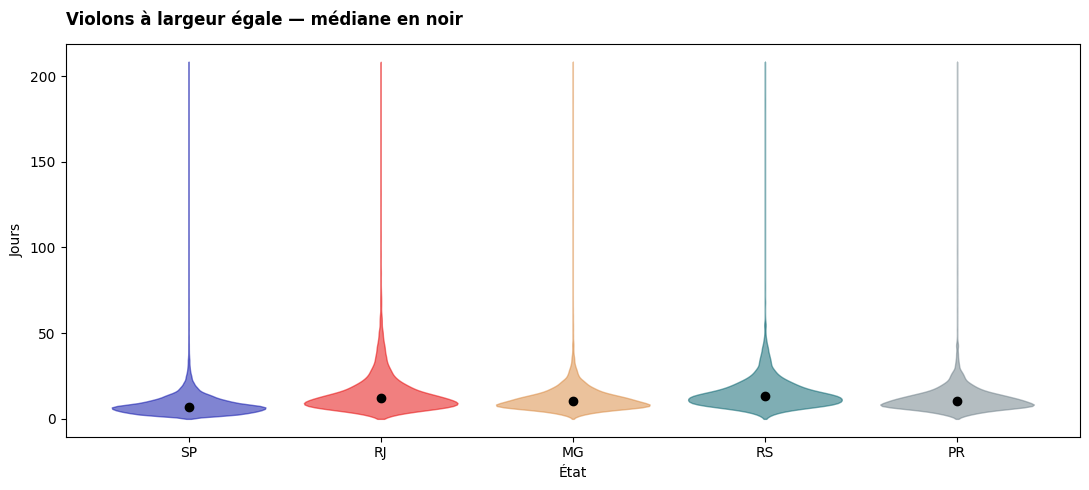

In [22]:
ID_GRAPHIQUE = '03_05'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
for j,s in enumerate(etats):
    largeur=.4*densites[s]/densites[s].max();ax.fill_betweenx(grille,j-largeur,j+largeur,color=palette[j],alpha=.5);ax.plot(j,a.loc[a.state.eq(s),'delai_jours'].median(),'ko')
ax.set_xticks(range(len(etats)),etats)
terminer(ax,'Violons à largeur égale — médiane en noir','État','Jours')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

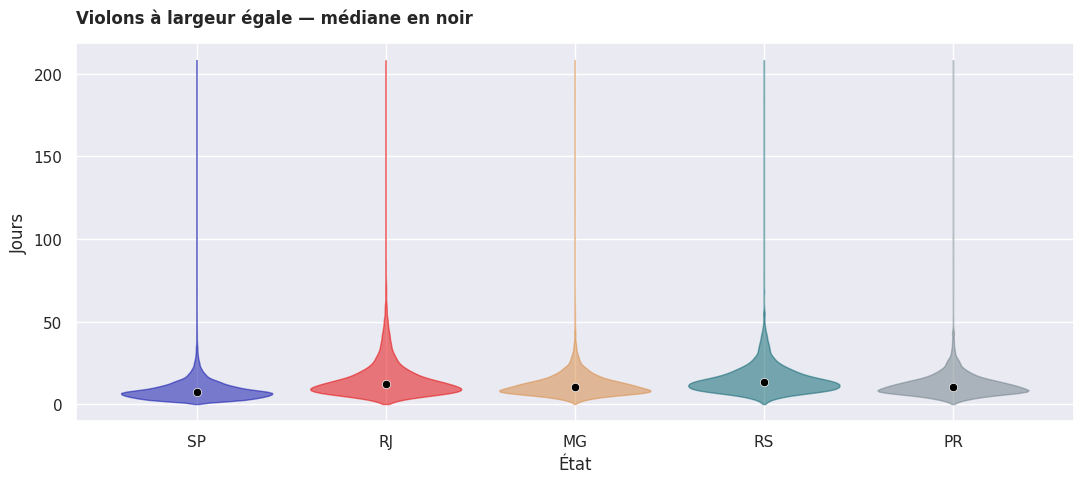

In [23]:
ID_GRAPHIQUE = '03_05'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
# Contours calculés en commun ; sns.scatterplot ajoute les médianes.
for j,s in enumerate(etats):
    largeur=.4*densites[s]/densites[s].max();ax.fill_betweenx(grille,j-largeur,j+largeur,color=palette[j],alpha=.5)
med=a.groupby('state').delai_jours.median().reindex(etats)
sns.scatterplot(x=np.arange(len(etats)),y=med.to_numpy(),color='black',ax=ax,legend=False)
ax.set_xticks(range(len(etats)),etats)
terminer(ax,'Violons à largeur égale — médiane en noir','État','Jours')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [24]:
ID_GRAPHIQUE = '03_05'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure()
for j,s in enumerate(etats):
    largeur=.4*densites[s]/densites[s].max();fig.add_trace(go.Scatter(x=np.r_[j-largeur,(j+largeur)[::-1]],y=np.r_[grille,grille[::-1]],fill='toself',mode='lines',name=s,line_color=palette[j],opacity=.6))
fig.add_trace(go.Scatter(x=list(range(len(etats))),y=[a.loc[a.state.eq(s),'delai_jours'].median() for s in etats],mode='markers',marker_color='black',name='Médiane'))
fig.update_xaxes(tickvals=list(range(len(etats))),ticktext=etats,title='État');fig.update_yaxes(title='Jours')
montrer_plotly(fig,'Violons à largeur égale — médiane en noir')

**À lire dans les trois variantes :** Comparer les formes de délai par état. Variables : état C + délai Q. Densités de Scott calculées sur une grille commune puis normalisées à largeur maximale égale : la largeur ne représente pas l’effectif.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>6 — Points individuels avec jitter</div></b>

Examiner 80 commandes par état, tirées avec une graine fixe. Variables : état C + délai Q. Le jitter est un déplacement graphique horizontal ; il ne modifie pas les délais.

In [25]:
population=donnees.loc[donnees.delai_jours.notna() & donnees.status.eq('delivered')].copy()
x=population.delai_jours.to_numpy()
assert len(x)>1
display(population.delai_jours.describe(percentiles=[.5,.9,.99]))
etats=population.state.value_counts().head(5).index.tolist()
a=population.loc[population.state.isin(etats)].copy()
display(a.groupby('state').delai_jours.agg(['size','median']))
ech=pd.concat([a.loc[a.state.eq(s)].sample(n=min(80,int(a.state.eq(s).sum())),random_state=SEED) for s in etats]).copy()
ech['x_jitter']=ech.state.map({s:j for j,s in enumerate(etats)}).astype(float)+np.random.default_rng(SEED).uniform(-.18,.18,len(ech))
display(ech.groupby('state').size().rename('n_affiche'))

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
50%         10.217477
90%         23.096377
99%         46.050262
max        209.628611
Name: delai_jours, dtype: float64

,size,median
state,,
MG,11354,10.313513
PR,4923,10.425509
RJ,12350,12.041644
RS,5344,13.177488
SP,40494,7.210272


state
MG    80
PR    80
RJ    80
RS    80
SP    80
Name: n_affiche, dtype: int64

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

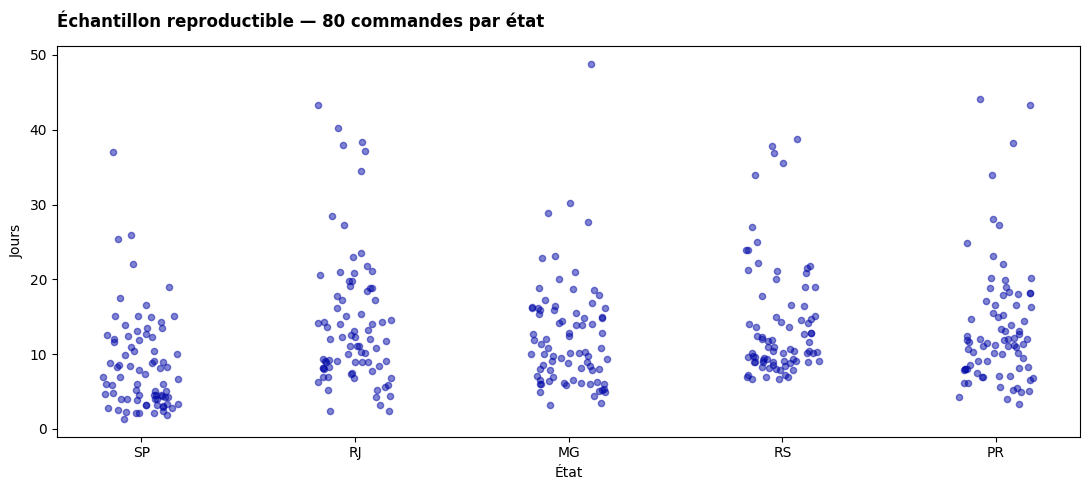

In [26]:
ID_GRAPHIQUE = '03_06'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.scatter(ech.x_jitter,ech.delai_jours,s=20,alpha=.5,color=palette[0]);ax.set_xticks(range(len(etats)),etats)
terminer(ax,'Échantillon reproductible — 80 commandes par état','État','Jours')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

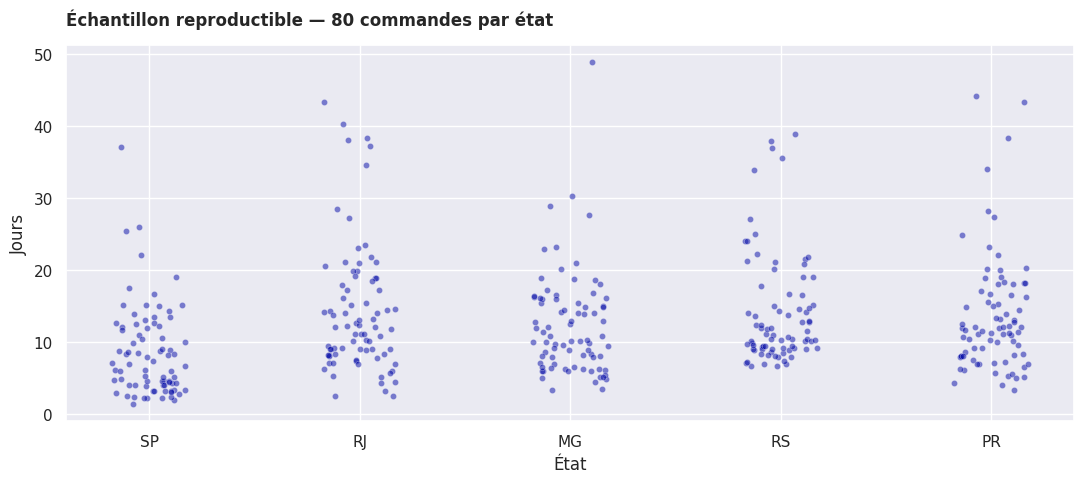

In [27]:
ID_GRAPHIQUE = '03_06'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.scatterplot(data=ech,x='x_jitter',y='delai_jours',s=20,alpha=.5,color=palette[0],ax=ax);ax.set_xticks(range(len(etats)),etats)
terminer(ax,'Échantillon reproductible — 80 commandes par état','État','Jours')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

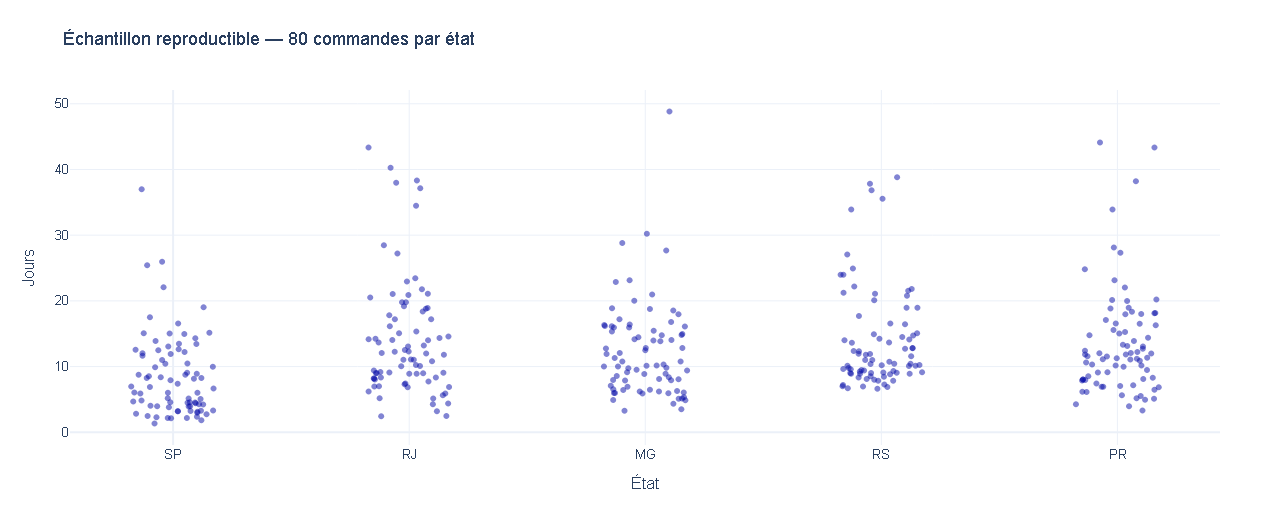

In [28]:
ID_GRAPHIQUE = '03_06'
BIBLIOTHEQUE = 'plotly'
fig=px.scatter(ech,x='x_jitter',y='delai_jours',hover_data=['state'],opacity=.5,labels={'delai_jours':'Jours'})
fig.update_xaxes(tickvals=list(range(len(etats))),ticktext=etats,title='État')
montrer_plotly(fig,'Échantillon reproductible — 80 commandes par état')

**À lire dans les trois variantes :** Examiner 80 commandes par état, tirées avec une graine fixe. Variables : état C + délai Q. Le jitter est un déplacement graphique horizontal ; il ne modifie pas les délais.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Synthèse et exercices</div></b>

1. Reformuler la question métier de chacun des six graphiques.
2. Modifier un filtre ou une période et expliquer son effet sur le dénominateur.
3. Choisir une variante pour un rapport imprimé et une pour un tableau de bord interactif.
4. Vérifier l’unité, l’effectif, les valeurs manquantes et le sens des encodages.

**Limites :** Les tables locales constituent la source ; aucune base de démonstration ne les remplace. Les articles sont agrégés au niveau commande avant jointure. Les commandes sans article ou sans livraison restent manquantes pour les mesures concernées. Les délais sont recalculés : les colonnes de durée préexistantes ne sont pas présumées documentées. L’unité monétaire BRL est une hypothèse de contexte ; les graphiques indiquent « montant source ».